In [2]:
#Load Libraries
library(Seurat)
library(SeuratDisk)
library(Signac)
library(Matrix)
library(future)
library(reticulate)
library(sceasy)
library(MuDataSeurat)
library(hdf5r)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(grid)
library(viridis)

#Set Options
options(future.globals.maxSize = 400000 * 1024^2) #for 400GB max size
plan("sequential")

#Set working directory
setwd("/storage1/fs1/jmillman/Active/DigitalTwin")

set.seed(777)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(Com

# Load Data

In [ ]:
data.muon <- readRDS("checkpoints/DT_muon_annotated.rds")
data.muon

An object of class Seurat 
95325 features across 401519 samples within 2 assays 
Active assay: RNA (17015 features, 5000 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC
 17 dimensional reductions calculated: RNAHARMONY, RNAINTEGRATED_LSI, RNAMULTIVI, RNAPCA, RNAUMAP, RNAUMAP.HARMONY, RNAUMAP.INTEGRATED.ATAC, RNAUMAP.MERGED.RNA, ATACHARMONY, ATACINTEGRATED_LSI, ATACMULTIVI, ATACPCA, ATACUMAP, ATACUMAP.HARMONY, ATACUMAP.INTEGRATED.ATAC, ATACUMAP.MERGED.RNA, umap.multivi

In [ ]:
table(data.muon@meta.data$dataset)


      Balboa_S5DT       Balboa_S5NT   Balboa_S7w0_A11    Balboa_S7w0_B3 
             1453              1460              4275              4034 
   Balboa_S7w0_B5   Balboa_S7w3_D18   Balboa_S7w3_D20   Balboa_S7w3_D25 
             3749              3236              3167              3806 
Balboa_S7w6_exp22 Balboa_S7w6_exp23     Multiome_s2d1     Multiome_s3d1 
             3096              2189             13237              4490 
    Multiome_s4d2     Multiome_s5d1     Multiome_s5d3     Multiome_s5d5 
             5698              6944              5440              6759 
    Multiome_s6d1     Multiome_s6d7    Multiome_s6d14    Punn_ESC_S6D14 
             6224              8089              9671             14259 
  Punn_iPSC_S6D14     Punn_scislet1     Punn_scislet2     Punn_scislet3 
             3963              8729              7688             11092 
   Punn_scisletw3    Punn_scisletw4        Veres_s3x1        Veres_s3x2 
             7089              5468              7

# Figures

## Metadata

In [25]:
meta <- data.frame(table(data.muon$day,data.muon$dataset,data.muon$protocol,data.muon$cellsource,data.muon$modality))

# Modify values a little bit
meta <- meta[meta$Freq != 0, ]
meta$Var1 <- gsub("Day","",meta$Var1)
meta$Var1 <- as.numeric(meta$Var1)
meta$Var3 <- gsub(".x1","",meta$Var3)
meta$Var3 <- gsub(".x2","",meta$Var3)

meta$Var6 <- paste(meta$Var4, meta$Var5, sep="_")
shape_mapping <- c("ESC_H1_accessibility"=0, "ESC_H1_expression"=12, "iPSC_Peking_expression"=6, "iPSC_WS4corr_expression"=2, 
                   'ESC_HUES8_expression'=10, "ESC_HUES8_paired"=16)  # You can customize the shapes this way

write.csv(meta, "outputs/DT/metadata_metrics.csv")

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


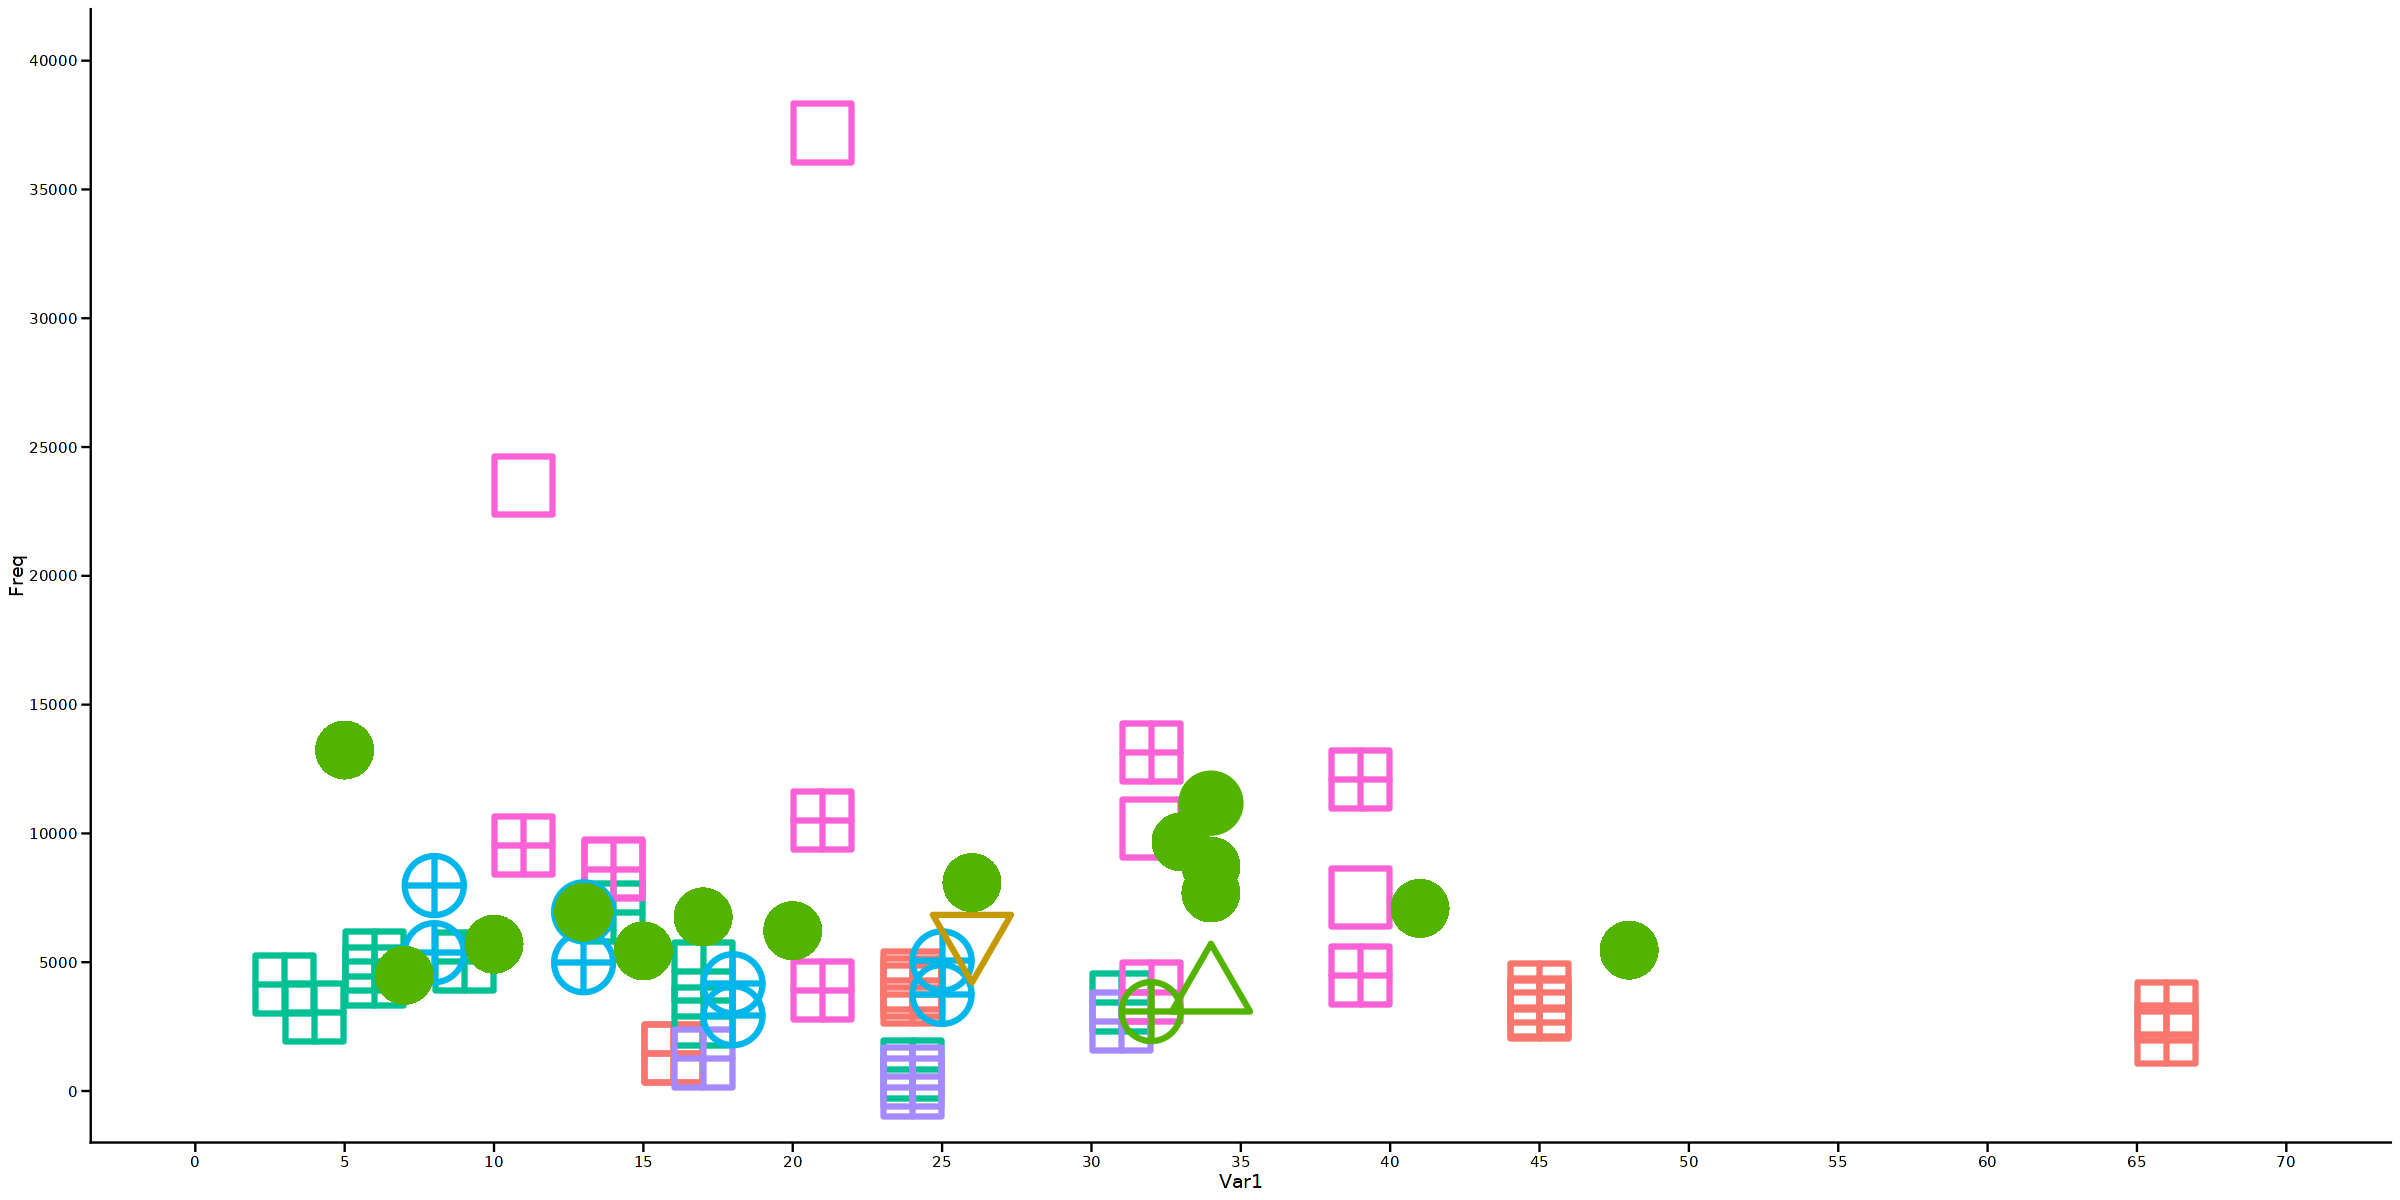

In [26]:
#Fig. 2B
options(repr.plot.width = 20, repr.plot.height = 10)
ggplot(data=meta, aes(x=Var1, y=Freq, color=Var3, shape=Var6)) + 
    geom_point(size=15, stroke=2.0) +
    scale_y_continuous(limits=c(0,40000),breaks=seq(0,40000,by=5000)) +
    scale_x_continuous(limits=c(0,70),breaks=seq(0,70,by=5)) +
    scale_shape_manual(values = shape_mapping) +
    theme_classic() + theme(axis.line=element_line(size=0.5), axis.ticks = element_line(size = 0.5), axis.ticks.length = unit(0.2, "cm")) + NoLegend()

## UMAPs

In [27]:
pal_celltype <- c(
  "Mesench." = "#ffbd00",  # yellow
  "Prolif."  = "#CC6677", # dusty rose / muted red
  "DE"       = "#a7defa", # light sky blue
  "GT"       = "#DDCC77", # warm sand / golden khaki
  "PP"       = "#402bad", # deep indigo
  "Exo" = "#117733", # forest green
  "UE"       = "#EE3377", # magenta / raspberry
  "eEP"      = "#fcb686", # light orange
  "lEP"      = '#cd853f', #Peru color
  "SIC"       = "#015f94", # royal blue
  "Beta"        = "#ba0c2f", # WashU red
  "Delta"        = "#7d9e31", # olive
  "Alpha"        = "#f55e07" # vivid orange
)

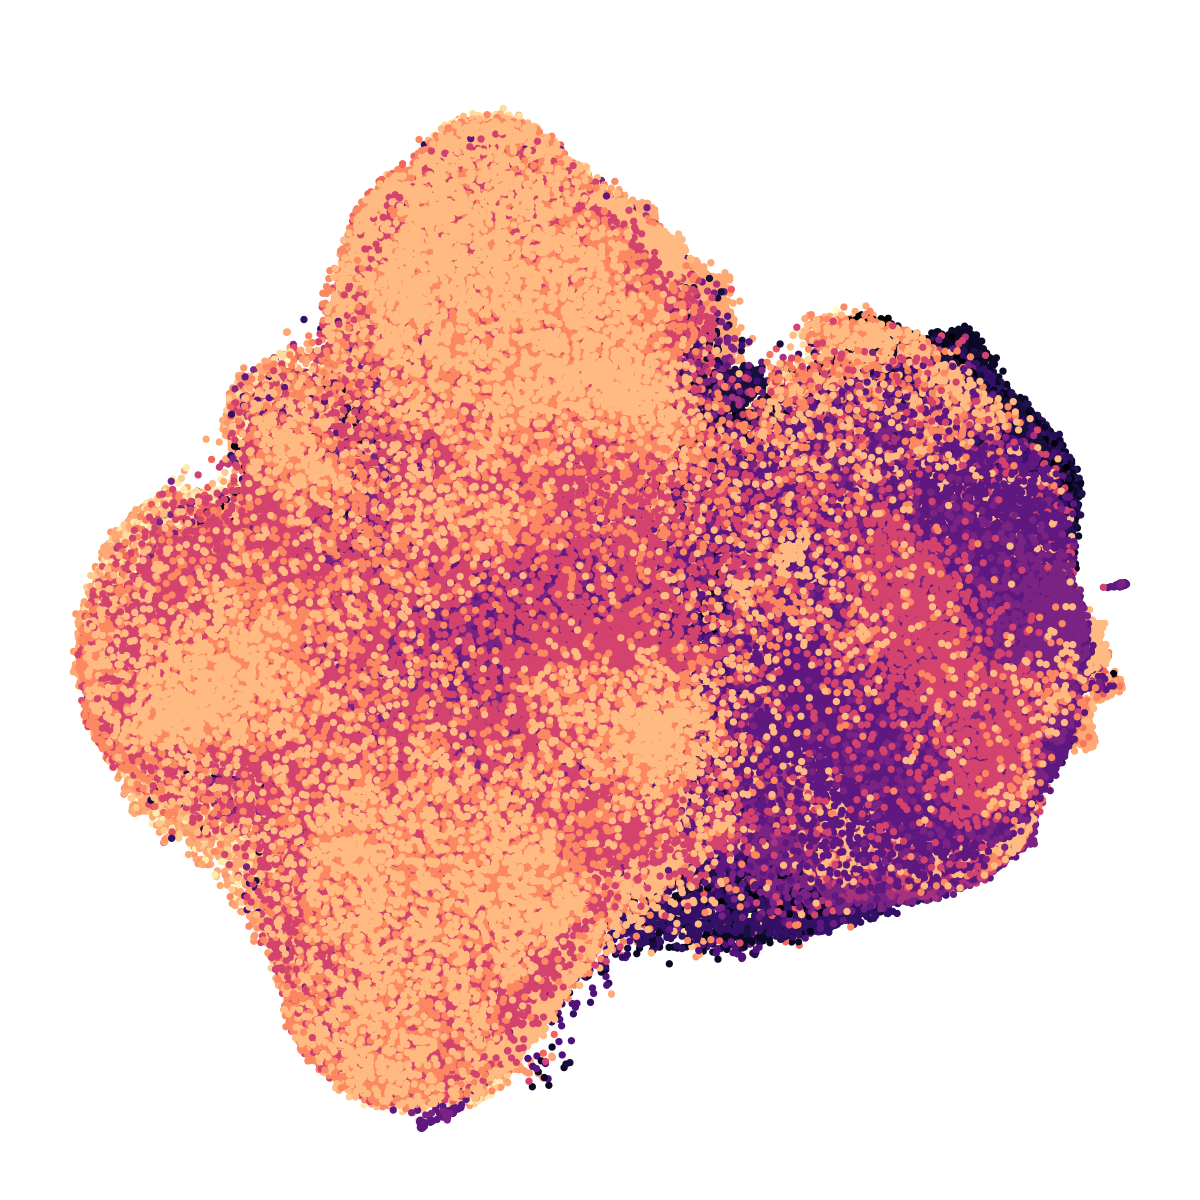

In [28]:
#Fig. 2C
options(repr.plot.width = 10, repr.plot.height = 10)
DimPlot(data.muon, reduction='umap.multivi', group.by="day", cols=magma(29), 
        label = FALSE, pt.size=0.8, raster=FALSE) + NoAxes() + ggtitle("") + NoLegend()

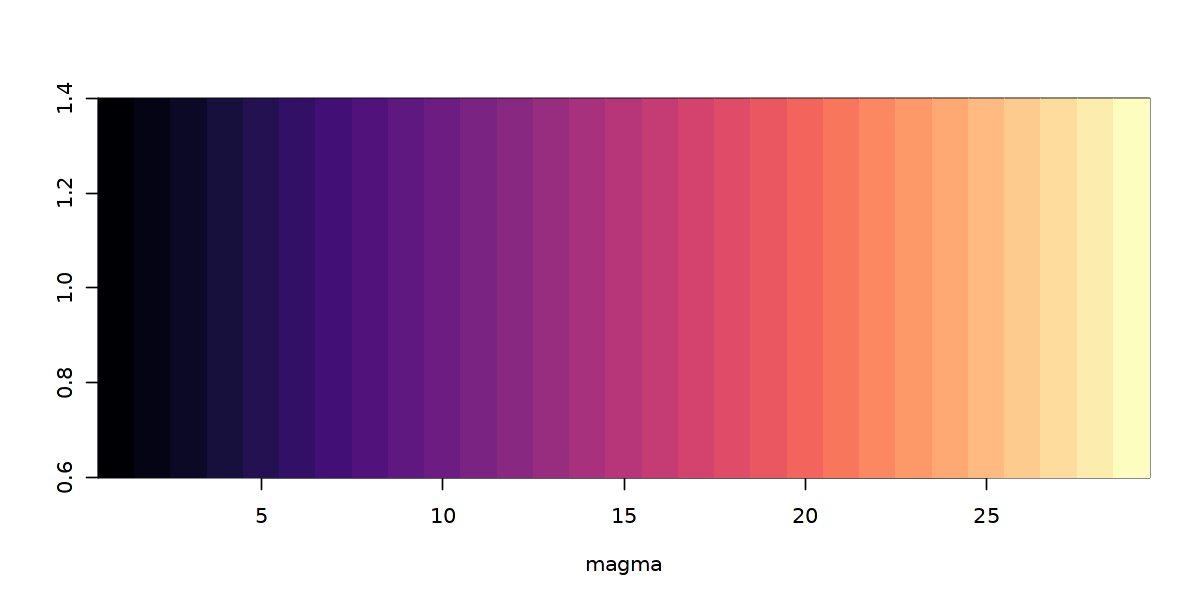

In [29]:
options(repr.plot.width = 10, repr.plot.height = 5)
image(1:29, 1, as.matrix(1:29),col = magma(29), xlab = 'magma', ylab = '')

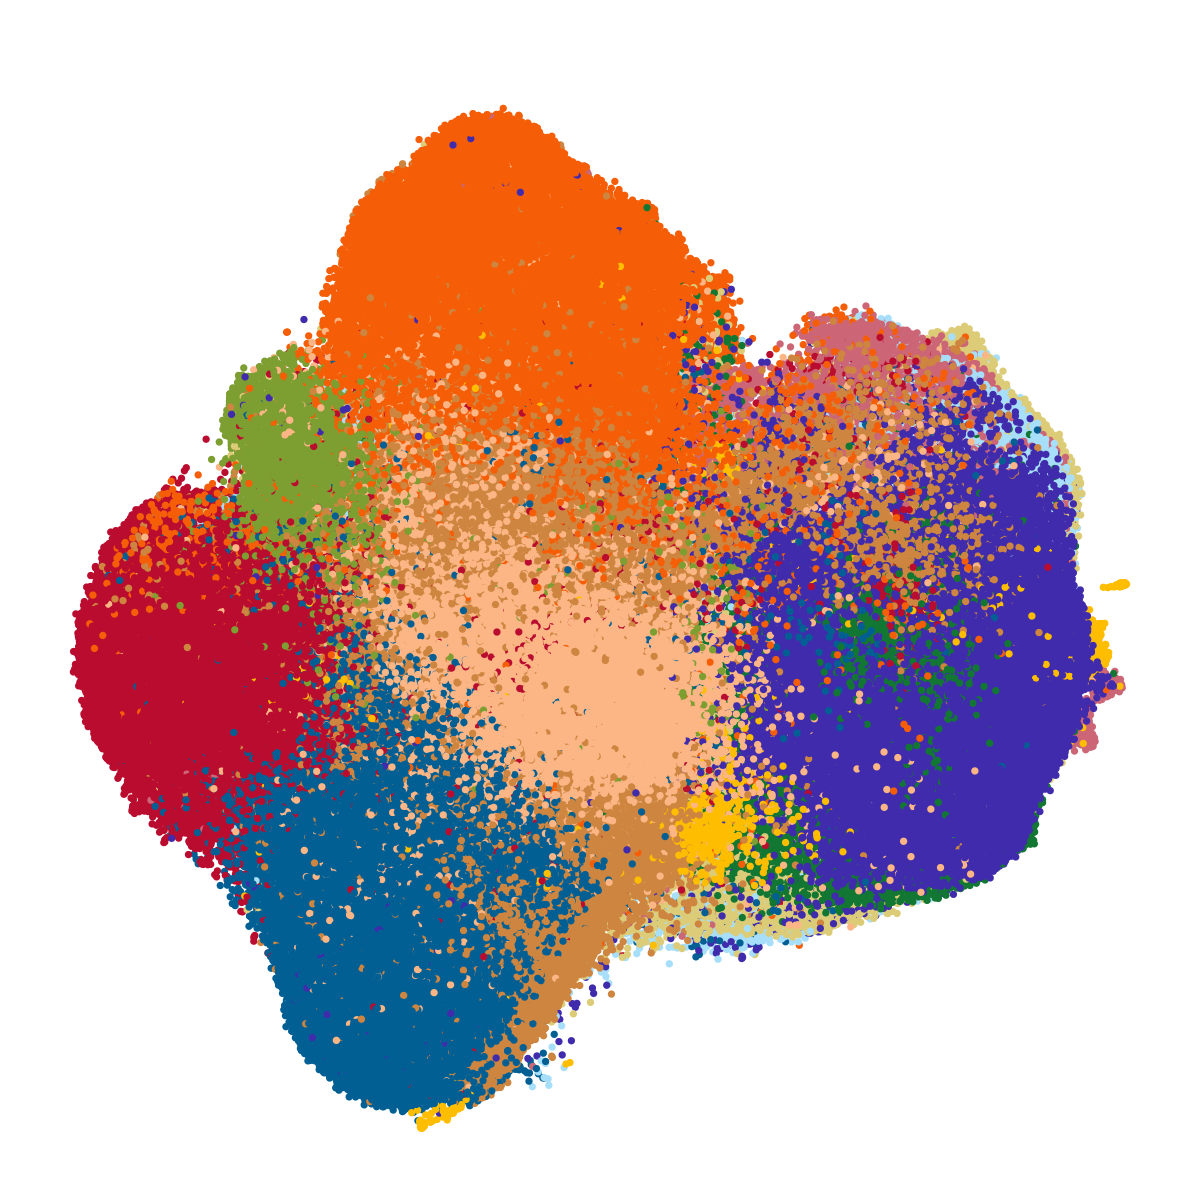

In [30]:
#Fig. 2D
options(repr.plot.width = 10, repr.plot.height = 10)
DimPlot(data.muon, reduction='umap.multivi', group.by="celltype_labelled_by_protocol", cols=pal_celltype, 
        label = FALSE, pt.size=0.8, raster=FALSE) + NoAxes() + ggtitle("") + NoLegend()

## Bar Graph

In [31]:
# Identify cells in cluster 18 and update their cell type
data.muon$celltype_labelled_by_protocol[data.muon$multivi_clusters == 18] <- 'Mesench.'

In [32]:
# Calculate cell type proportions
prop.celltype <- data.frame(prop.table(table(data.muon$day,data.muon$celltype_labelled_by_protocol)))

colnames(prop.celltype) <- c("Day","CellType", "Frac")
prop.celltype$CellType <- as.character(prop.celltype$CellType)

prop.celltype$CellType <- factor(prop.celltype$CellType, levels=c("DE","GT", "Prolif.", "Mesench.",
                                                                 "PP","Exo","eEP",
                                                                 "lEP","UE",
                                                                  "Delta", "Alpha","Beta","SIC"))

prop.plot <- ggplot(prop.celltype, aes(fill=factor(CellType), y=Frac, x=Day)) +
  geom_bar(position="fill", stat="identity", width = .9) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 7)) +
  labs(x = "", y = "Proportion of cells") +
  guides(fill = guide_legend(title="CellType"))+ 
  scale_fill_manual(values=pal_celltype) + NoLegend()

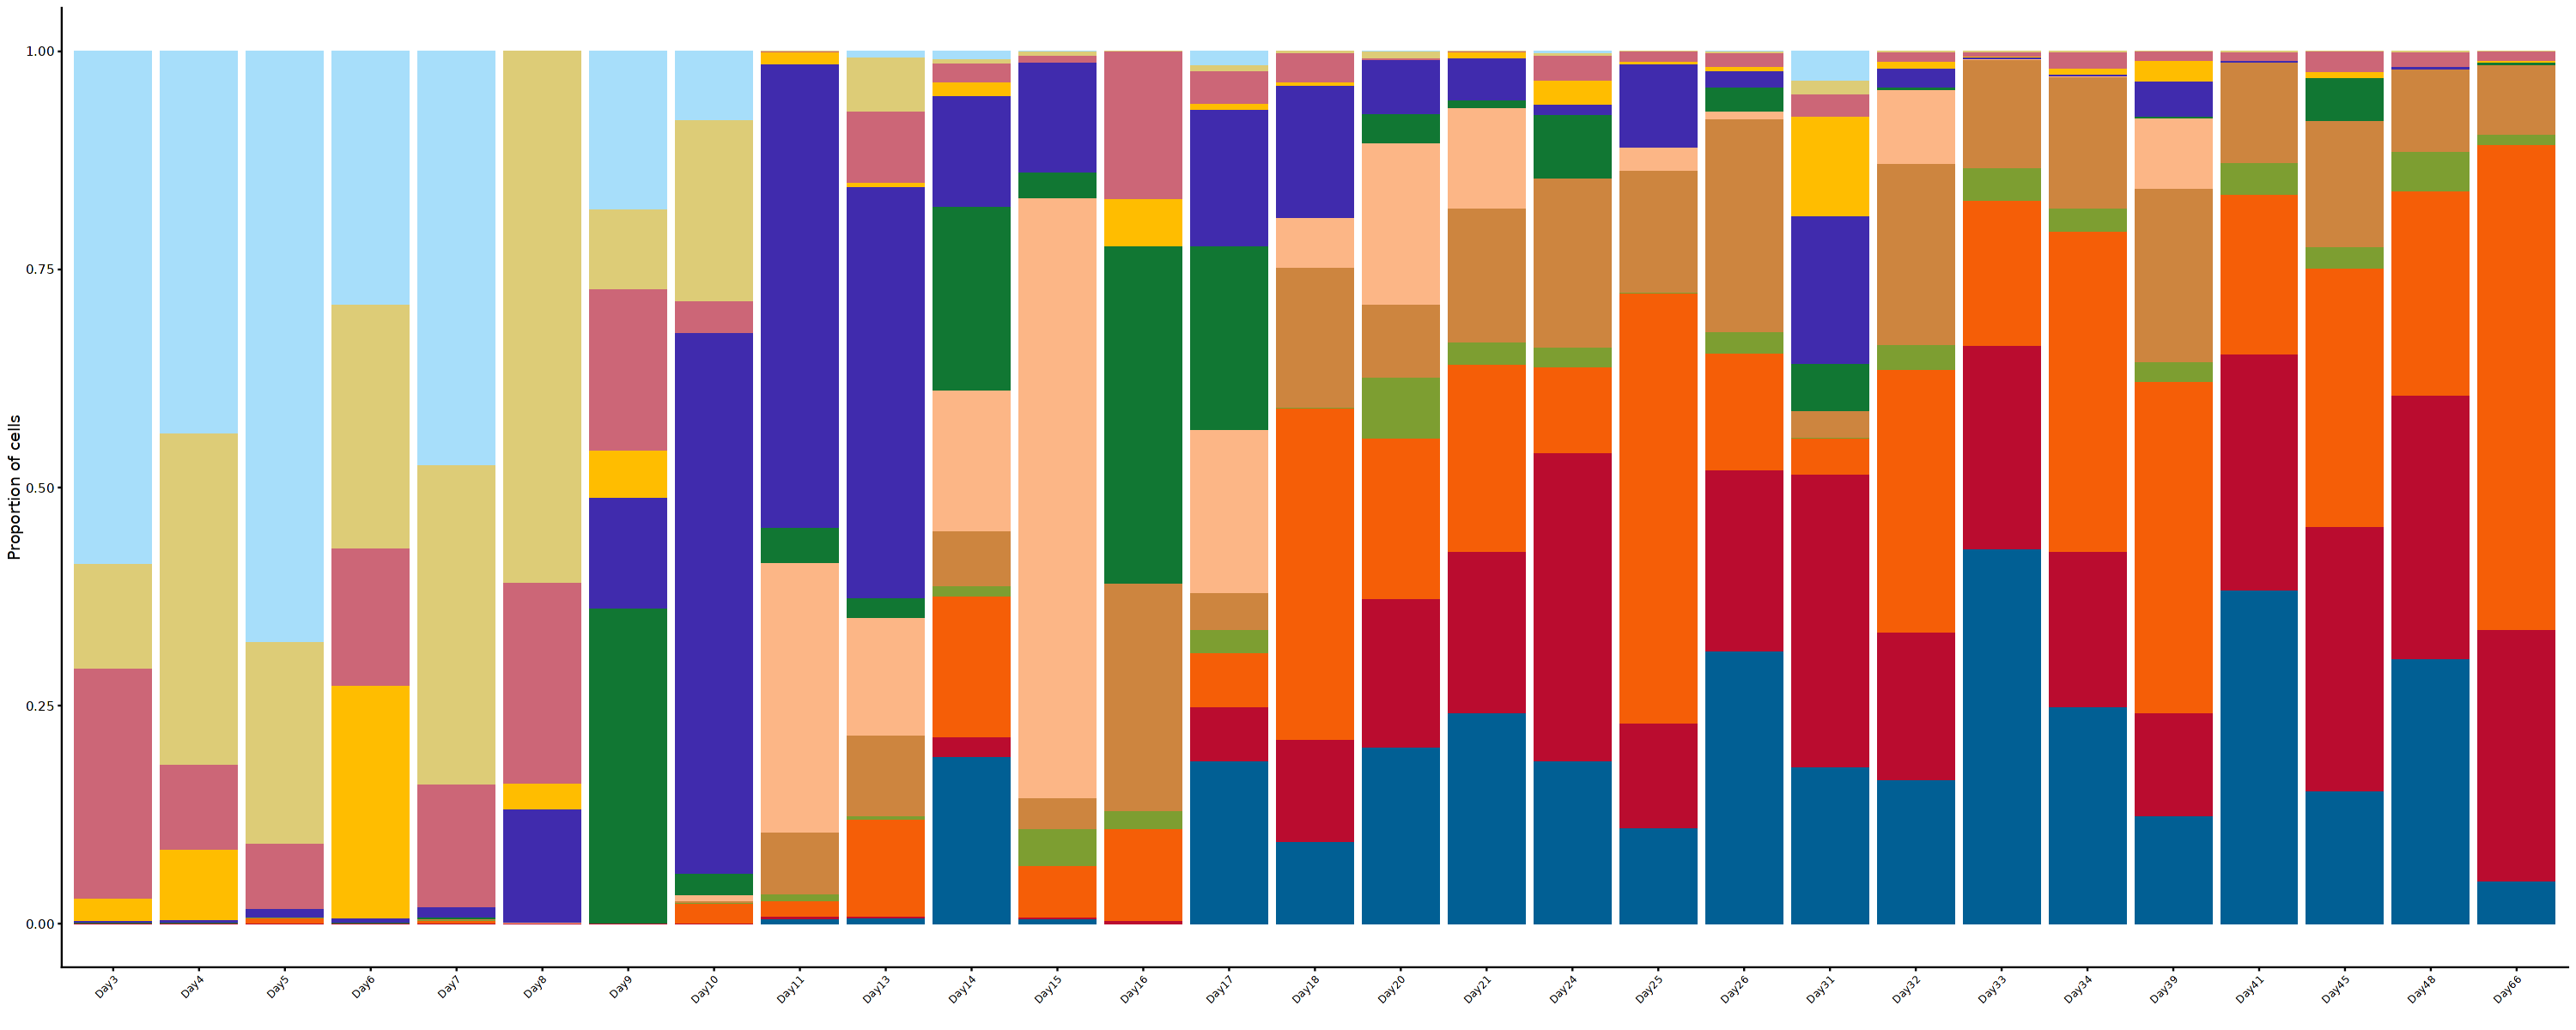

In [33]:
#Fig. 2E
options(repr.plot.width = 25, repr.plot.height = 10)
prop.plot

## Dot Plot

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message in plot_theme(plot):
“The `panel.margin` theme element is not defined in the element hierarchy.”


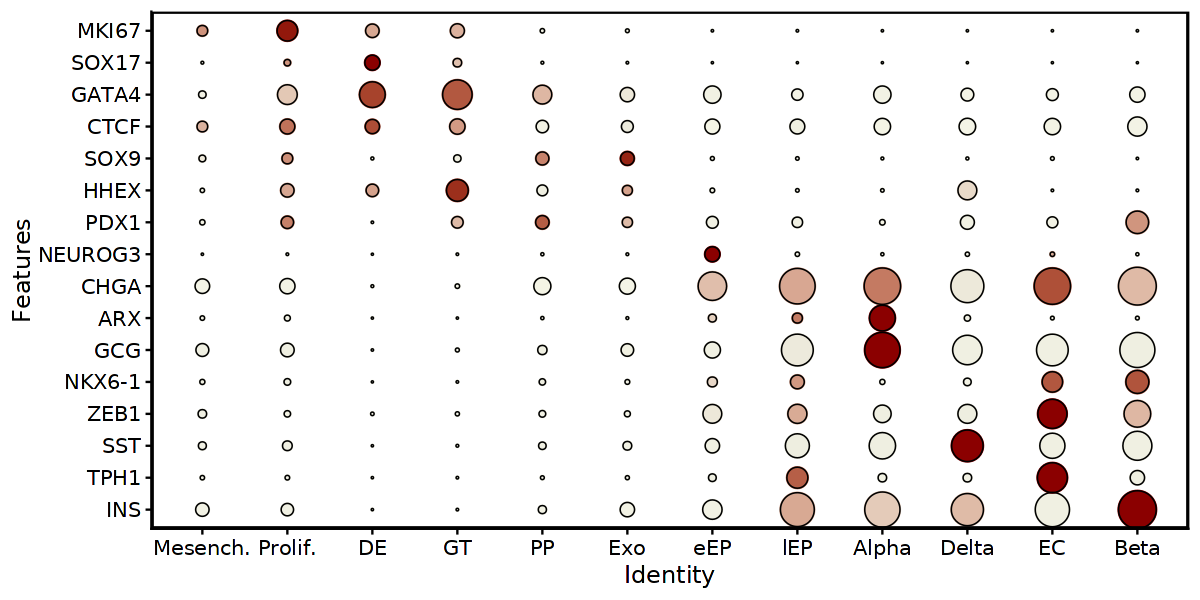

In [34]:
# Gene Expression Dotplot
DefaultAssay(data.muon) <- 'RNA'
Idents(data.muon) <- "celltype_labelled_by_protocol"

genes = c('INS','TPH1','SST','ZEB1','NKX6-1','GCG','ARX','CHGA','NEUROG3','PDX1','HHEX','SOX9','CTCF','GATA4','SOX17','MKI67')    
    
#'TOP2A', 'MKI67', 'SOX17','CER1','GATA6','GATA4', 'SOX9','PDX1','NEUROG3','CHGA','SLC18A1','TPH1','NKX6-1','INS','HHEX','SST','ARX','GCG')

options(repr.plot.width = 10, repr.plot.height = 5)

DotPlot(data.muon, features = genes, dot.scale = 10, scale=TRUE) + NoLegend() +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +  coord_flip() + #scale_size_binned(breaks = c(25, 50, 75)) +
  scale_colour_gradient2(low = "ivory", mid = "ivory2", high = "red4") + #NoAxes() +
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white"))) + 
theme(panel.border=element_rect(colour="black",fill=NA,size=1),panel.margin=unit(0,"cm"),panel.background=element_rect(fill="white")) 

In [35]:
#Check differential gene expression over time
DefaultAssay(data.muon) <- 'RNA'
Idents(data.muon) <- "celltype_labelled_by_protocol"

differential.expression <- FindAllMarkers(object = data.muon, only.pos = TRUE)

write.csv(differential.expression,"outputs/ClusterMarkers/DT_DEGs_CellTypesProtocol.csv", row.names = TRUE)
rm(differential.expression)
gc()

Calculating cluster Mesench.

Calculating cluster Prolif.

Calculating cluster DE

Calculating cluster GT

Calculating cluster PP

Calculating cluster Exo

Calculating cluster eEP

Calculating cluster lEP

Calculating cluster Alpha

Calculating cluster Delta

Calculating cluster EC

Calculating cluster Beta

Warning message:
“No DE genes identified”
Warning message:
“The following tests were not performed: ”
Warning message:
“When testing Mesench. versus all:
	The `slot` argument of `GetAssayData()` was deprecated in SeuratObject 5.0.0 and is now defunct.Please use the `layer` argument instead.”
Warning message:
“When testing Prolif. versus all:
	The `slot` argument of `GetAssayData()` was deprecated in SeuratObject 5.0.0 and is now defunct.Please use the `layer` argument instead.”
Warning message:
“When testing DE versus all:
	The `slot` argument of `GetAssayData()` was deprecated in SeuratObject 5.0.0 and is now defunct.Please use the `layer` argument instead.”
Warning message:
“When

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9659212,515.9,14117776,754.0,14117776,754.0
Vcells,6404704095,48864.1,13283151826,101342.5,13282818239,101339.9
